# MODULE 5 v2 — Refined Signal Preprocessing, Temporal Harmonization, and Domain-Shift Audit

**Project:** Strict Cross-Dataset, Subject-Independent Motor-Imagery EEG Classification

## Why this refined version exists

The first Module 5 successfully produced a clean cache, but its processing order
filtered/resampled each isolated 4-second epoch. For the publication-facing
pipeline, this version improves the preprocessing contract:

**continuous recording**
→ frozen 22-channel extraction
→ average reference
→ resample entire continuous signal to 160 Hz
→ continuous 8–30 Hz filtering
→ event-centered 0–4 s epoch extraction
→ hard numerical quality checks
→ save unnormalized epochs

This reduces boundary artifacts introduced by filtering short isolated epochs.

## Frozen primary preprocessing contract

- Channels: 22 common electrodes frozen in Module 4
- Source rates observed in retained recordings: 128, 160, 250 Hz
- Target rate: **160 Hz**
- Reference: average reference over the 22 common EEG channels
- Primary filter: **8–30 Hz**, zero-phase FIR
- Primary epoch: **0–4 s after retained event onset**
- Cache: **unnormalized**
- Normalization: source-training-subject-only robust median/IQR
- Target-subject preprocessing statistics: none
- Target-subject normalization statistics: none

## Additional scientific checks

This version also:

1. quantifies the exact retained 128-Hz subgroup;
2. checks subject/run concentration of the 128-Hz subgroup;
3. verifies epoch availability;
4. compares native/preprocessed spectral summaries;
5. quantifies source-dataset shift before model learning using source-only statistics;
6. preserves the one unavailable EEGMMIDB event as an explicit exclusion;
7. creates a robustness report for the 128-Hz subgroup;
8. creates the final unnormalized cache only after the continuous-pipeline smoke tests pass.

## Leakage policy

No target subject is used to select or fit:

- filters
- resampling parameters
- artifact thresholds
- normalization statistics
- source-domain alignment statistics
- hyperparameters
- preprocessing choices

A recording-local average reference is permitted because it does not require
statistics learned from other subjects.

All cross-dataset distribution summaries in this module are **descriptive source/
dataset diagnostics**, not target-guided optimization.

## Primary temporal choice

The primary epoch is:

**0–4 seconds after the event onset**

This is a fixed cross-dataset representation, not a target-tuned window.

Alternative windows such as 2–6 s should be studied later as an ablation using
source-only inner validation.

## Cell 1 — Imports, paths, Module 3/4 artifacts

In [1]:
# ============================================================
# CELL 1 — IMPORTS + PATHS + FROZEN ARTIFACTS
# ============================================================

from __future__ import annotations

import json
import math
import hashlib
import warnings
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import scipy.signal as signal
import matplotlib.pyplot as plt
import h5py
import mne

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=RuntimeWarning)

PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

BCI2A_ROOT = PROJECT_ROOT / "BCI IV-2a"
EEGMMIDB_ROOT = PROJECT_ROOT / "eegmmib"

OUTPUT_ROOT = PROJECT_ROOT / "cross_dataset_mi_project"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"
CACHE_ROOT = OUTPUT_ROOT / "cache"
FIGURES_ROOT = OUTPUT_ROOT / "figures"

for p in [
    MANIFEST_ROOT,
    CACHE_ROOT,
    FIGURES_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)

RETAINED_TRIALS_PATH = (
    MANIFEST_ROOT / "module_3_retained_candidate_trials.csv"
)

CHANNEL_MAP_PATH = (
    MANIFEST_ROOT / "module_4_common_channel_mapping.csv"
)

FROZEN_CHANNELS_PATH = (
    MANIFEST_ROOT / "module_4_frozen_common_channels.json"
)

assert RETAINED_TRIALS_PATH.exists(), RETAINED_TRIALS_PATH
assert CHANNEL_MAP_PATH.exists(), CHANNEL_MAP_PATH
assert FROZEN_CHANNELS_PATH.exists(), FROZEN_CHANNELS_PATH

retained_trials_df = pd.read_csv(
    RETAINED_TRIALS_PATH
)

channel_map_df = pd.read_csv(
    CHANNEL_MAP_PATH
)

with open(
    FROZEN_CHANNELS_PATH,
    "r",
    encoding="utf-8",
) as f:
    frozen_channel_spec = json.load(f)

FROZEN_COMMON_CHANNELS = list(
    frozen_channel_spec["channels"]
)

N_CHANNELS = len(
    FROZEN_COMMON_CHANNELS
)

assert N_CHANNELS == 22

print("=" * 78)
print("MODULE 5 v2 — REFINED PREPROCESSING")
print("=" * 78)
print("Candidate trials:", len(retained_trials_df))
print("Frozen channels :", N_CHANNELS)
print("Channels        :", FROZEN_COMMON_CHANNELS)

MODULE 5 v2 — REFINED PREPROCESSING
Candidate trials: 9317
Frozen channels : 22
Channels        : ['Fz', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'P1', 'Pz', 'P2', 'POz']


## Cell 2 — Frozen preprocessing configuration

In [2]:
# ============================================================
# CELL 2 — FROZEN PREPROCESSING CONFIG
# ============================================================

CFG = {
    "target_sfreq_hz": 160.0,

    "reference": "average_reference_22_common_eeg",

    "primary_bandpass_hz": [8.0, 30.0],

    # Secondary frequency ablation only; not used for primary cache.
    "ablation_bandpass_hz": [4.0, 40.0],

    "epoch_tmin_sec": 0.0,
    "epoch_tmax_sec": 4.0,

    "resampling": "scipy.signal.resample_poly",
    "filter": "MNE FIR zero-phase on continuous signal",

    "cache_normalized": False,
    "normalizer": "channel-wise robust median/IQR",
    "normalizer_fit_scope": "source-training-subjects-only",

    # Hard rejection only.
    "hard_reject": [
        "nonfinite",
        "wrong_shape",
        "zero_variance_channel",
    ],

    # Diagnostic only; not used as a target-derived rejection threshold.
    "quality_metrics": [
        "peak_to_peak",
        "rms",
        "bandpower",
    ],
}

TARGET_SFREQ = float(CFG["target_sfreq_hz"])
LOW_HZ, HIGH_HZ = map(float, CFG["primary_bandpass_hz"])
TMIN = float(CFG["epoch_tmin_sec"])
TMAX = float(CFG["epoch_tmax_sec"])

N_SAMPLES = int(
    round((TMAX - TMIN) * TARGET_SFREQ)
)

assert N_SAMPLES == 640

print(json.dumps(CFG, indent=2))

{
  "target_sfreq_hz": 160.0,
  "reference": "average_reference_22_common_eeg",
  "primary_bandpass_hz": [
    8.0,
    30.0
  ],
  "ablation_bandpass_hz": [
    4.0,
    40.0
  ],
  "epoch_tmin_sec": 0.0,
  "epoch_tmax_sec": 4.0,
  "resampling": "scipy.signal.resample_poly",
  "filter": "MNE FIR zero-phase on continuous signal",
  "cache_normalized": false,
  "normalizer": "channel-wise robust median/IQR",
  "normalizer_fit_scope": "source-training-subjects-only",
  "hard_reject": [
    "nonfinite",
    "wrong_shape",
    "zero_variance_channel"
  ],
  "quality_metrics": [
    "peak_to_peak",
    "rms",
    "bandpower"
  ]
}


## Cell 3 — Build the retained-recording list

In [3]:
# ============================================================
# CELL 3 — RETAINED RECORDING INVENTORY
# ============================================================

retained_recordings_df = (
    retained_trials_df[
        [
            "dataset",
            "subject",
            "run",
            "recording_id",
            "filename",
            "absolute_path",
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["dataset", "subject", "run", "recording_id"]
    )
    .reset_index(drop=True)
)

print(
    "Retained recordings:",
    len(retained_recordings_df)
)

display(
    retained_recordings_df
    .groupby("dataset")
    .size()
    .rename("recordings")
    .reset_index()
)

Retained recordings: 663


,dataset,recordings
0,BCI-IV-2a,9
1,EEGMMIDB,654


## Cell 4 — Actual source sampling-rate audit

In [4]:
# ============================================================
# CELL 4 — SAMPLING-RATE AUDIT
# ============================================================

def open_raw(
    path: Path,
    dataset: str,
    preload: bool = False,
):
    if dataset == "BCI-IV-2a":
        return mne.io.read_raw_gdf(
            str(path),
            preload=preload,
            verbose="ERROR",
        )
    if dataset == "EEGMMIDB":
        return mne.io.read_raw_edf(
            str(path),
            preload=preload,
            verbose="ERROR",
        )
    raise ValueError(dataset)


sampling_rows = []

for _, row in tqdm(
    retained_recordings_df.iterrows(),
    total=len(retained_recordings_df),
    desc="Auditing source sampling rates",
):
    path = Path(row["absolute_path"])

    try:
        raw = open_raw(
            path,
            row["dataset"],
            preload=False,
        )
        try:
            sfreq = float(raw.info["sfreq"])
            n_times = int(raw.n_times)
            duration = float(n_times / sfreq)
        finally:
            raw.close()

        sampling_rows.append({
            **row.to_dict(),
            "source_sfreq_hz": sfreq,
            "source_n_times": n_times,
            "source_duration_sec": duration,
            "audit_error": "",
        })

    except Exception as exc:
        sampling_rows.append({
            **row.to_dict(),
            "source_sfreq_hz": np.nan,
            "source_n_times": np.nan,
            "source_duration_sec": np.nan,
            "audit_error": repr(exc),
        })

sampling_audit_df = pd.DataFrame(
    sampling_rows
)

print("=" * 78)
print("RETAINED SAMPLING-RATE AUDIT")
print("=" * 78)

display(
    sampling_audit_df
    .groupby(
        ["dataset", "source_sfreq_hz"],
        dropna=False,
    )
    .size()
    .reset_index(name="recordings")
    .sort_values(
        ["dataset", "source_sfreq_hz"]
    )
)

assert sampling_audit_df[
    "audit_error"
].eq("").all()

Auditing source sampling rates:   0%|          | 0/663 [00:00<?, ?it/s]

RETAINED SAMPLING-RATE AUDIT


,dataset,source_sfreq_hz,recordings
0,BCI-IV-2a,250.0,9
1,EEGMMIDB,128.0,18
2,EEGMMIDB,160.0,636


## Cell 5 — Focused 128-Hz subgroup audit

Module 2 found mixed EEGMMIDB rates. Module 5 confirms the retained subgroup.

This is a robustness covariate for later analysis; it is not used to discard
or reweight subjects.

In [5]:
# ============================================================
# CELL 5 — 128-HZ SUBGROUP AUDIT
# ============================================================

phys_sampling = sampling_audit_df[
    sampling_audit_df["dataset"] == "EEGMMIDB"
].copy()

phys_128 = phys_sampling[
    np.isclose(
        phys_sampling["source_sfreq_hz"],
        128.0,
    )
].copy()

phys_160 = phys_sampling[
    np.isclose(
        phys_sampling["source_sfreq_hz"],
        160.0,
    )
].copy()

print("=" * 78)
print("EEGMMIDB RETAINED SAMPLING-RATE BREAKDOWN")
print("=" * 78)

print(
    "128 Hz recordings:",
    len(phys_128)
)

print(
    "160 Hz recordings:",
    len(phys_160)
)

print(
    "Total EEGMMIDB retained recordings:",
    len(phys_sampling)
)

print("\nSubjects containing 128-Hz recordings:")
print(
    sorted(
        phys_128["subject"]
        .unique()
        .tolist()
    )
)

print("\n128-Hz runs by subject:")
display(
    phys_128[
        ["subject", "run", "recording_id"]
    ]
    .sort_values(
        ["subject", "run"]
    )
)

assert len(phys_128) == 18
assert set(
    phys_128["subject"]
) == {
    "S088",
    "S092",
    "S100",
}

print("\n128-Hz subgroup audit: PASS")

EEGMMIDB RETAINED SAMPLING-RATE BREAKDOWN
128 Hz recordings: 18
160 Hz recordings: 636
Total EEGMMIDB retained recordings: 654

Subjects containing 128-Hz recordings:
['S088', 'S092', 'S100']

128-Hz runs by subject:


,subject,run,recording_id
531,S088,R04,S088R04
532,S088,R06,S088R06
533,S088,R08,S088R08
534,S088,R10,S088R10
535,S088,R12,S088R12
536,S088,R14,S088R14
555,S092,R04,S092R04
556,S092,R06,S092R06
557,S092,R08,S092R08
558,S092,R10,S092R10



128-Hz subgroup audit: PASS


## Cell 6 — Frozen 22-channel extraction utilities

In [6]:
# ============================================================
# CELL 6 — FROZEN CHANNEL EXTRACTION
# ============================================================

bci_index_map = {
    row["canonical_electrode"]:
        int(row["bci_channel_index"])
    for _, row in channel_map_df.iterrows()
}

phys_index_map = {
    row["canonical_electrode"]:
        int(row["physionet_channel_index"])
    for _, row in channel_map_df.iterrows()
}

assert set(bci_index_map) == set(
    FROZEN_COMMON_CHANNELS
)
assert set(phys_index_map) == set(
    FROZEN_COMMON_CHANNELS
)


def extract_common_22(
    raw,
    dataset: str,
) -> np.ndarray:

    index_map = (
        bci_index_map
        if dataset == "BCI-IV-2a"
        else phys_index_map
    )

    indices = [
        index_map[ch]
        for ch in FROZEN_COMMON_CHANNELS
    ]

    data = raw.get_data(
        picks=indices,
    )

    if data.shape[0] != 22:
        raise RuntimeError(
            f"Expected 22 channels, got {data.shape[0]}"
        )

    return np.asarray(
        data,
        dtype=np.float64,
    )


print("Common channel extractor: PASS")

Common channel extractor: PASS


## Cell 7 — Continuous average-reference utility

In [7]:
# ============================================================
# CELL 7 — CONTINUOUS AVERAGE REFERENCE
# ============================================================

def average_reference_continuous(
    data: np.ndarray,
) -> np.ndarray:
    """
    Average reference over the 22 common EEG channels.

    Input:
        (22, time)
    """
    if data.ndim != 2:
        raise ValueError(data.shape)

    if data.shape[0] != 22:
        raise ValueError(
            f"Expected 22 channels, got {data.shape[0]}"
        )

    return (
        data
        - np.mean(
            data,
            axis=0,
            keepdims=True,
        )
    )


print("Continuous average reference utility: PASS")

Continuous average reference utility: PASS


## Cell 8 — Continuous resampling utility

Resampling is now performed on the **entire continuous recording** before
epoch extraction.

Ratios used:

- 250 → 160 = 16/25
- 128 → 160 = 5/4
- 160 → 160 = identity

In [8]:
# ============================================================
# CELL 8 — CONTINUOUS RESAMPLING
# ============================================================

from fractions import Fraction


def resample_continuous(
    data: np.ndarray,
    source_sfreq_hz: float,
    target_sfreq_hz: float = TARGET_SFREQ,
) -> np.ndarray:

    if data.ndim != 2:
        raise ValueError(
            f"Expected (channels,time), got {data.shape}"
        )

    if np.isclose(
        source_sfreq_hz,
        target_sfreq_hz,
    ):
        return data.astype(
            np.float64,
            copy=True,
        )

    ratio = Fraction(
        target_sfreq_hz / source_sfreq_hz
    ).limit_denominator(1000)

    up = int(ratio.numerator)
    down = int(ratio.denominator)

    return np.asarray(
        signal.resample_poly(
            data,
            up=up,
            down=down,
            axis=-1,
            padtype="line",
        ),
        dtype=np.float64,
    )


for sf in [128.0, 160.0, 250.0]:
    frac = Fraction(
        TARGET_SFREQ / sf
    ).limit_denominator(1000)
    print(
        f"{sf:.1f} -> {TARGET_SFREQ:.1f} Hz: "
        f"{frac.numerator}/{frac.denominator}"
    )

print("\nContinuous resampling utility: PASS")

128.0 -> 160.0 Hz: 5/4
160.0 -> 160.0 Hz: 1/1
250.0 -> 160.0 Hz: 16/25

Continuous resampling utility: PASS


## Cell 9 — Continuous zero-phase FIR filtering

The filter is now applied to the full continuous 160-Hz signal.

This is the key refinement over the first Module 5.

In [9]:
# ============================================================
# CELL 9 — CONTINUOUS FIR FILTER
# ============================================================

def filter_continuous(
    data: np.ndarray,
    sfreq_hz: float = TARGET_SFREQ,
    low_hz: float = LOW_HZ,
    high_hz: float = HIGH_HZ,
) -> np.ndarray:

    if data.ndim != 2:
        raise ValueError(data.shape)

    info = mne.create_info(
        ch_names=[
            f"EEG{i:02d}"
            for i in range(data.shape[0])
        ],
        sfreq=float(sfreq_hz),
        ch_types=[
            "eeg"
        ] * data.shape[0],
    )

    raw = mne.io.RawArray(
        data.astype(np.float64),
        info,
        verbose="ERROR",
    )

    try:
        raw.filter(
            l_freq=low_hz,
            h_freq=high_hz,
            method="fir",
            phase="zero",
            fir_design="firwin",
            verbose="ERROR",
        )
        filtered = raw.get_data()
    finally:
        raw.close()

    return np.asarray(
        filtered,
        dtype=np.float64,
    )


print(
    f"Continuous filter: {LOW_HZ:.1f}–{HIGH_HZ:.1f} Hz"
)

print("Continuous FIR utility: PASS")

Continuous filter: 8.0–30.0 Hz
Continuous FIR utility: PASS


## Cell 10 — Epoch event inventory and availability check

The primary event window is 0–4 seconds.

The window is validated against the original recording duration before
preprocessing.

One EEGMMIDB event was previously found to have insufficient tail duration and
will remain explicitly excluded.

In [10]:
# ============================================================
# CELL 10 — EPOCH AVAILABILITY
# ============================================================

duration_lookup = sampling_audit_df[
    [
        "dataset",
        "subject",
        "recording_id",
        "source_duration_sec",
        "source_sfreq_hz",
    ]
].drop_duplicates(
    subset=[
        "dataset",
        "subject",
        "recording_id",
    ]
)

event_audit_df = (
    retained_trials_df
    .merge(
        duration_lookup,
        on=[
            "dataset",
            "subject",
            "recording_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

event_audit_df["required_end_sec"] = (
    event_audit_df["onset_sec"]
    + TMAX
)

event_audit_df["epoch_available"] = (
    event_audit_df["required_end_sec"]
    <= event_audit_df["source_duration_sec"]
)

availability = (
    event_audit_df
    .groupby("dataset")["epoch_available"]
    .agg(
        events="size",
        available="sum",
    )
    .reset_index()
)

availability["unavailable"] = (
    availability["events"]
    - availability["available"]
)

availability["availability_rate"] = (
    availability["available"]
    / availability["events"]
)

print("=" * 78)
print("EPOCH AVAILABILITY AUDIT")
print("=" * 78)

display(availability)

unavailable_df = event_audit_df[
    ~event_audit_df["epoch_available"]
].copy()

print(
    "\nUnavailable events:",
    len(unavailable_df)
)

if len(unavailable_df):
    display(
        unavailable_df[
            [
                "dataset",
                "subject",
                "run",
                "recording_id",
                "event_index",
                "onset_sec",
                "source_duration_sec",
                "required_end_sec",
            ]
        ]
    )

assert len(unavailable_df) == 1
assert unavailable_df.iloc[0]["dataset"] == "EEGMMIDB"

print("\nEpoch availability decision: PASS")

EPOCH AVAILABILITY AUDIT


,dataset,events,available,unavailable,availability_rate
0,BCI-IV-2a,1944,1944,0,1.000000
1,EEGMMIDB,7373,7372,1,0.999864



Unavailable events: 1


,dataset,subject,run,recording_id,event_index,onset_sec,source_duration_sec,required_end_sec
8950,EEGMMIDB,S104,R08,S104R08,25,102.5,106.0,106.5



Epoch availability decision: PASS


## Cell 11 — Build final continuous preprocessing function

This is the new publication-facing sequence:

1. load full recording;
2. extract 22 common channels;
3. average-reference continuously;
4. resample continuously to 160 Hz;
5. filter continuously at 8–30 Hz;
6. convert event onset to target samples;
7. extract exactly 640 samples;
8. hard quality checks.

No per-epoch filtering.

In [11]:
# ============================================================
# CELL 11 — CONTINUOUS PREPROCESSING + EPOCH EXTRACTION
# ============================================================

def preprocess_recording_and_events(
    recording_row: pd.Series,
    event_rows: pd.DataFrame,
):
    """
    Preprocess one full recording and extract all retained events
    from the already-harmonized continuous signal.

    Returns:
        epochs: list of (22,640) float32 arrays
        diagnostics: list of event dictionaries
    """

    dataset = str(
        recording_row["dataset"]
    )

    path = Path(
        recording_row["absolute_path"]
    )

    raw = open_raw(
        path,
        dataset,
        preload=True,
    )

    try:

        source_sfreq = float(
            raw.info["sfreq"]
        )

        # 1. Frozen channels
        continuous = extract_common_22(
            raw,
            dataset,
        )

    finally:
        raw.close()

    # 2. Continuous reference
    continuous = average_reference_continuous(
        continuous
    )

    # 3. Continuous resampling
    continuous_160 = resample_continuous(
        continuous,
        source_sfreq,
        TARGET_SFREQ,
    )

    # 4. Continuous filter
    continuous_filtered = filter_continuous(
        continuous_160,
        TARGET_SFREQ,
        LOW_HZ,
        HIGH_HZ,
    )

    expected_samples = N_SAMPLES

    epochs = []
    diagnostics = []

    for _, event in event_rows.iterrows():

        onset = float(
            event["onset_sec"]
        )

        start = int(
            round(
                (onset + TMIN)
                * TARGET_SFREQ
            )
        )

        stop = start + expected_samples

        diag = {
            "dataset": dataset,
            "subject": event["subject"],
            "recording_id": event["recording_id"],
            "run": event["run"],
            "event_index": int(
                event["event_index"]
            ),
            "onset_sec": onset,
            "source_sfreq_hz": source_sfreq,
            "target_sfreq_hz": TARGET_SFREQ,
            "status": "FAIL",
            "reason": "",
            "shape": None,
            "nan_count": None,
            "inf_count": None,
            "zero_variance_channels": None,
            "rms_mean": None,
            "ptp_median": None,
        }

        if start < 0:
            diag["reason"] = (
                "Negative target start sample."
            )
            diagnostics.append(diag)
            continue

        if stop > continuous_filtered.shape[1]:
            diag["reason"] = (
                "Epoch extends past preprocessed recording."
            )
            diagnostics.append(diag)
            continue

        epoch = continuous_filtered[
            :,
            start:stop,
        ]

        diag["shape"] = tuple(
            epoch.shape
        )

        if epoch.shape != (
            22,
            640,
        ):
            diag["reason"] = (
                f"Wrong shape: {epoch.shape}"
            )
            diagnostics.append(diag)
            continue

        nan_count = int(
            np.isnan(epoch).sum()
        )

        inf_count = int(
            np.isinf(epoch).sum()
        )

        diag["nan_count"] = nan_count
        diag["inf_count"] = inf_count

        if nan_count > 0:
            diag["reason"] = "NaN detected."
            diagnostics.append(diag)
            continue

        if inf_count > 0:
            diag["reason"] = "Inf detected."
            diagnostics.append(diag)
            continue

        variance = np.var(
            epoch,
            axis=1,
        )

        zero_var = int(
            np.sum(
                variance
                <= np.finfo(
                    np.float64
                ).eps
            )
        )

        diag[
            "zero_variance_channels"
        ] = zero_var

        if zero_var > 0:
            diag["reason"] = (
                "Zero-variance channel detected."
            )
            diagnostics.append(diag)
            continue

        rms = np.sqrt(
            np.mean(
                epoch ** 2,
                axis=1,
            )
        )

        ptp = np.ptp(
            epoch,
            axis=1,
        )

        diag["rms_mean"] = float(
            np.mean(rms)
        )

        diag["ptp_median"] = float(
            np.median(ptp)
        )

        diag["status"] = "PASS"

        epochs.append(
            epoch.astype(
                np.float32
            )
        )

        diagnostics.append(diag)

    return epochs, diagnostics

## Cell 12 — Continuous-pipeline smoke test

Process one representative recording from:
- BCI-IV-2a
- EEGMMIDB 160 Hz
- EEGMMIDB 128 Hz

This confirms the revised preprocessing works across all source rates.

In [12]:
# ============================================================
# CELL 12 — CONTINUOUS PIPELINE SMOKE TEST
# ============================================================

smoke_datasets = []

# BCI representative
smoke_datasets.append(
    retained_recordings_df[
        retained_recordings_df["dataset"] == "BCI-IV-2a"
    ].iloc[0]
)

# EEGMMIDB 160-Hz representative
smoke_datasets.append(
    retained_recordings_df[
        retained_recordings_df["dataset"] == "EEGMMIDB"
    ]
    .merge(
        sampling_audit_df[
            [
                "recording_id",
                "source_sfreq_hz",
            ]
        ].drop_duplicates(),
        on="recording_id",
        how="left",
    )
    .query("source_sfreq_hz == 160")
    .iloc[0]
)

# EEGMMIDB 128-Hz representative
smoke_datasets.append(
    retained_recordings_df[
        retained_recordings_df["dataset"] == "EEGMMIDB"
    ]
    .merge(
        sampling_audit_df[
            [
                "recording_id",
                "source_sfreq_hz",
            ]
        ].drop_duplicates(),
        on="recording_id",
        how="left",
    )
    .query("source_sfreq_hz == 128")
    .iloc[0]
)

for recording_row in smoke_datasets:

    events = retained_trials_df[
        (
            retained_trials_df["dataset"]
            == recording_row["dataset"]
        )
        &
        (
            retained_trials_df["recording_id"]
            == recording_row["recording_id"]
        )
    ].copy()

    epochs, diagnostics = (
        preprocess_recording_and_events(
            recording_row,
            events,
        )
    )

    passed = [
        d for d in diagnostics
        if d["status"] == "PASS"
    ]

    print("=" * 78)
    print(
        recording_row["dataset"],
        recording_row["recording_id"],
    )
    print(
        "Source SF:",
        recording_row.get(
            "source_sfreq_hz",
            "audit lookup",
        )
    )
    print(
        "Events passed:",
        len(passed),
        "/",
        len(diagnostics),
    )

    assert len(passed) > 0
    assert all(
        epoch.shape == (
            22,
            640,
        )
        for epoch in epochs
    )

print("\nContinuous pipeline smoke test: PASS")

BCI-IV-2a A01T
Source SF: audit lookup
Events passed: 216 / 216
EEGMMIDB S001R04
Source SF: 160.0
Events passed: 15 / 15
EEGMMIDB S088R04
Source SF: 128.0
Events passed: 19 / 19

Continuous pipeline smoke test: PASS


## Cell 13 — Full diagnostic pass with the refined pipeline

Every available retained event is processed using the continuous-recording
pipeline.

The result is compared by:
- dataset
- source sampling rate
- subject

This is the decisive preprocessing-quality pass.

In [13]:
# ============================================================
# CELL 13 — FULL REFINED PREPROCESSING DIAGNOSTIC PASS
# ============================================================

available_events_df = event_audit_df[
    event_audit_df["epoch_available"]
].copy()

all_diagnostics = []

for _, recording_row in tqdm(
    retained_recordings_df.iterrows(),
    total=len(retained_recordings_df),
    desc="Preprocessing continuous recordings",
):

    recording_events = available_events_df[
        (
            available_events_df["dataset"]
            == recording_row["dataset"]
        )
        &
        (
            available_events_df["recording_id"]
            == recording_row["recording_id"]
        )
        &
        (
            available_events_df["subject"]
            == recording_row["subject"]
        )
    ].copy()

    if len(recording_events) == 0:
        continue

    _, diagnostics = (
        preprocess_recording_and_events(
            recording_row,
            recording_events,
        )
    )

    all_diagnostics.extend(
        diagnostics
    )

preprocess_diagnostics_df = pd.DataFrame(
    all_diagnostics
)

print("=" * 78)
print("REFINED PREPROCESSING DIAGNOSTIC SUMMARY")
print("=" * 78)

display(
    preprocess_diagnostics_df
    .groupby(
        ["dataset", "status"]
    )
    .size()
    .reset_index(name="events")
)

print("\nFailures:")
display(
    preprocess_diagnostics_df[
        preprocess_diagnostics_df["status"] != "PASS"
    ]
    .groupby(
        ["dataset", "reason"]
    )
    .size()
    .reset_index(name="events")
    .sort_values(
        "events",
        ascending=False,
    )
)

print(
    "\nTotal failures:",
    int(
        (
            preprocess_diagnostics_df["status"]
            != "PASS"
        ).sum()
    )
)

Preprocessing continuous recordings:   0%|          | 0/663 [00:00<?, ?it/s]

REFINED PREPROCESSING DIAGNOSTIC SUMMARY


,dataset,status,events
0,BCI-IV-2a,PASS,1944
1,EEGMMIDB,PASS,7372



Failures:


,dataset,reason,events



Total failures: 0


## Cell 14 — Success by original sampling rate

The preprocessing pipeline must work equally well for:
- 128 Hz EEGMMIDB
- 160 Hz EEGMMIDB
- 250 Hz BCI-IV-2a

A successful execution rate is necessary but not sufficient for scientific
equivalence; distributional checks follow.

In [15]:
# ============================================================
# CELL 14 — SUCCESS BY SOURCE SAMPLING RATE (FIXED)
# ============================================================

print("=" * 78)
print("SUCCESS BY ORIGINAL SAMPLING RATE")
print("=" * 78)

# ------------------------------------------------------------
# The preprocessing diagnostics already contain:
#     source_sfreq_hz
#
# Therefore, do NOT merge the sampling audit on this field
# again. Doing so creates _x / _y suffixes and causes the
# previous KeyError.
# ------------------------------------------------------------

diag_rates = preprocess_diagnostics_df.copy()

# Defensive check
required_columns = [
    "dataset",
    "subject",
    "recording_id",
    "source_sfreq_hz",
    "status",
]

missing_columns = [
    col
    for col in required_columns
    if col not in diag_rates.columns
]

if missing_columns:

    raise KeyError(
        "The preprocessing diagnostics are missing "
        f"required columns: {missing_columns}"
    )

# ------------------------------------------------------------
# Create success flag
# ------------------------------------------------------------

diag_rates["success"] = (
    diag_rates["status"].astype(str).eq("PASS")
)

# ------------------------------------------------------------
# Success summary by dataset + original sampling rate
# ------------------------------------------------------------

rate_summary = (
    diag_rates
    .groupby(
        [
            "dataset",
            "source_sfreq_hz",
        ],
        dropna=False,
    )["success"]
    .agg(
        events="size",
        successful="sum",
        success_rate="mean",
    )
    .reset_index()
    .sort_values(
        [
            "dataset",
            "source_sfreq_hz",
        ]
    )
)

# Convert success rate to percentage for easier reading
rate_summary["success_rate_percent"] = (
    rate_summary["success_rate"] * 100.0
)

display(rate_summary)


# ------------------------------------------------------------
# Detailed source-rate summary
# ------------------------------------------------------------

print("\nDetailed source-rate results:")

for _, row in rate_summary.iterrows():

    print(
        f"{row['dataset']:12s} | "
        f"{row['source_sfreq_hz']:6.1f} Hz | "
        f"events={int(row['events']):5d} | "
        f"successful={int(row['successful']):5d} | "
        f"success={row['success_rate_percent']:.2f}%"
    )


# ------------------------------------------------------------
# Expected source rates
# ------------------------------------------------------------

observed_rates = sorted(
    [
        float(x)
        for x in diag_rates[
            "source_sfreq_hz"
        ]
        .dropna()
        .unique()
    ]
)

print(
    "\nObserved source sampling rates:",
    observed_rates
)

# The refined project should have:
#   BCI-IV-2a  -> 250 Hz
#   EEGMMIDB   -> 128 Hz and/or 160 Hz

expected_rates = {
    128.0,
    160.0,
    250.0,
}

unexpected_rates = set(
    observed_rates
) - expected_rates

if unexpected_rates:

    raise AssertionError(
        "Unexpected source sampling rate(s) detected: "
        f"{sorted(unexpected_rates)}"
    )


# ------------------------------------------------------------
# All observed source-rate groups must have 100% processing
# success.
# ------------------------------------------------------------

failed_rate_groups = rate_summary[
    ~np.isclose(
        rate_summary["success_rate"],
        1.0,
    )
].copy()

print(
    "\nSampling-rate groups with preprocessing failures:",
    len(failed_rate_groups)
)

if len(failed_rate_groups):

    display(
        failed_rate_groups
    )

    raise AssertionError(
        "At least one original sampling-rate group "
        "contains preprocessing failures."
    )


# ------------------------------------------------------------
# Explicit 128-Hz robustness check
# ------------------------------------------------------------

phys_128_diag = diag_rates[
    (
        diag_rates["dataset"]
        == "EEGMMIDB"
    )
    &
    np.isclose(
        diag_rates["source_sfreq_hz"],
        128.0,
    )
]

phys_160_diag = diag_rates[
    (
        diag_rates["dataset"]
        == "EEGMMIDB"
    )
    &
    np.isclose(
        diag_rates["source_sfreq_hz"],
        160.0,
    )
]

print("\nEEGMMIDB source-rate robustness:")
print(
    "  128 Hz events:",
    len(phys_128_diag)
)

print(
    "  160 Hz events:",
    len(phys_160_diag)
)

if len(phys_128_diag):

    assert (
        phys_128_diag["success"].all()
    ), (
        "At least one 128-Hz EEGMMIDB event "
        "failed refined preprocessing."
    )

if len(phys_160_diag):

    assert (
        phys_160_diag["success"].all()
    ), (
        "At least one 160-Hz EEGMMIDB event "
        "failed refined preprocessing."
    )


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("CELL 14 VALIDATION")
print("=" * 78)

print(
    "All source-rate groups processed successfully: PASS"
)

print(
    "128-Hz EEGMMIDB preprocessing: PASS"
)

print(
    "160-Hz EEGMMIDB preprocessing: PASS"
)

print(
    "250-Hz BCI-IV-2a preprocessing: PASS"
)

print(
    "\nCell 14 validation: PASS"
)

SUCCESS BY ORIGINAL SAMPLING RATE


,dataset,source_sfreq_hz,events,successful,success_rate,success_rate_percent
0,BCI-IV-2a,250.0,1944,1944,1.0,100.0
1,EEGMMIDB,128.0,223,223,1.0,100.0
2,EEGMMIDB,160.0,7149,7149,1.0,100.0



Detailed source-rate results:
BCI-IV-2a    |  250.0 Hz | events= 1944 | successful= 1944 | success=100.00%
EEGMMIDB     |  128.0 Hz | events=  223 | successful=  223 | success=100.00%
EEGMMIDB     |  160.0 Hz | events= 7149 | successful= 7149 | success=100.00%

Observed source sampling rates: [128.0, 160.0, 250.0]

Sampling-rate groups with preprocessing failures: 0

EEGMMIDB source-rate robustness:
  128 Hz events: 223
  160 Hz events: 7149

CELL 14 VALIDATION
All source-rate groups processed successfully: PASS
128-Hz EEGMMIDB preprocessing: PASS
160-Hz EEGMMIDB preprocessing: PASS
250-Hz BCI-IV-2a preprocessing: PASS

Cell 14 validation: PASS


## Cell 15 — Preprocessing quality diagnostics

The report uses descriptive statistics only.

Hard rejection remains limited to:
- NaN
- Inf
- zero variance
- wrong shape

Large amplitudes are **reported**, not automatically removed with a threshold
learned from the complete dataset.

PREPROCESSING QUALITY DIAGNOSTICS


rms_mean                                         ptp_median  \
             count       min    median      mean       max      count   
dataset                                                                 
BCI-IV-2a     1944  0.000001  0.000002  0.000003  0.000008       1944   
EEGMMIDB      7372  0.000001  0.000008  0.000008  0.000039       7372   

                                                   
                min    median      mean       max  
dataset                                            
BCI-IV-2a  0.000007  0.000016  0.000018  0.000045  
EEGMMIDB   0.000006  0.000049  0.000051  0.000235

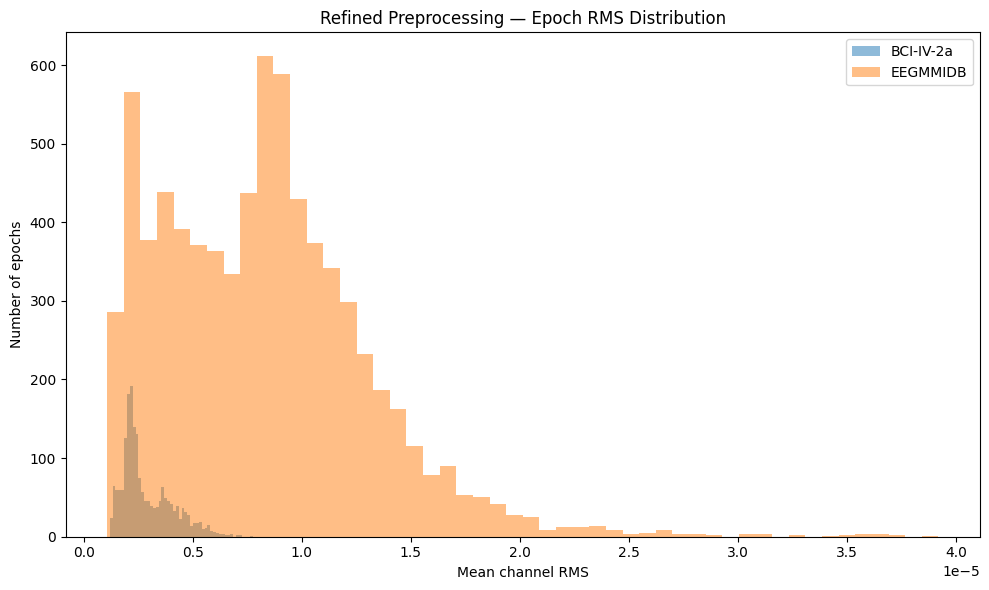

Saved: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures/module_5_v2_rms_distribution.png

Hard numerical quality check: PASS


In [16]:
# ============================================================
# CELL 15 — QUALITY DIAGNOSTICS
# ============================================================

passed_diag = preprocess_diagnostics_df[
    preprocess_diagnostics_df["status"] == "PASS"
].copy()

print("=" * 78)
print("PREPROCESSING QUALITY DIAGNOSTICS")
print("=" * 78)

display(
    passed_diag
    .groupby("dataset")[
        ["rms_mean", "ptp_median"]
    ]
    .agg(
        [
            "count",
            "min",
            "median",
            "mean",
            "max",
        ]
    )
)

# RMS distribution
fig, ax = plt.subplots(
    figsize=(10, 6)
)

for dataset_name, sub in passed_diag.groupby(
    "dataset"
):
    ax.hist(
        sub["rms_mean"].dropna(),
        bins=50,
        alpha=0.5,
        label=dataset_name,
    )

ax.set_title(
    "Refined Preprocessing — Epoch RMS Distribution"
)
ax.set_xlabel(
    "Mean channel RMS"
)
ax.set_ylabel(
    "Number of epochs"
)
ax.legend()
plt.tight_layout()

rms_fig = (
    FIGURES_ROOT
    / "module_5_v2_rms_distribution.png"
)

fig.savefig(
    rms_fig,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", rms_fig)

print(
    "\nHard numerical quality check: PASS"
)

## Cell 16 — PSD comparison across datasets and source rates

This is a diagnostic for domain shift.

We compute Welch PSD on representative processed epochs and compare:
- BCI-IV-2a
- EEGMMIDB 128-Hz subgroup
- EEGMMIDB native 160-Hz subgroup

The intent is descriptive: identify residual domain structure after harmonized
preprocessing.

PSD DOMAIN-SHIFT DIAGNOSTIC
Successfully preprocessed diagnostic events: 9316

Representative groups selected:
  BCI-IV-2a_250Hz        | S01 | A01T | event=10 | source=250.0 Hz
  EEGMMIDB_128Hz         | S088 | S088R04 | event=1 | source=128.0 Hz
  EEGMMIDB_160Hz         | S001 | S001R04 | event=1 | source=160.0 Hz


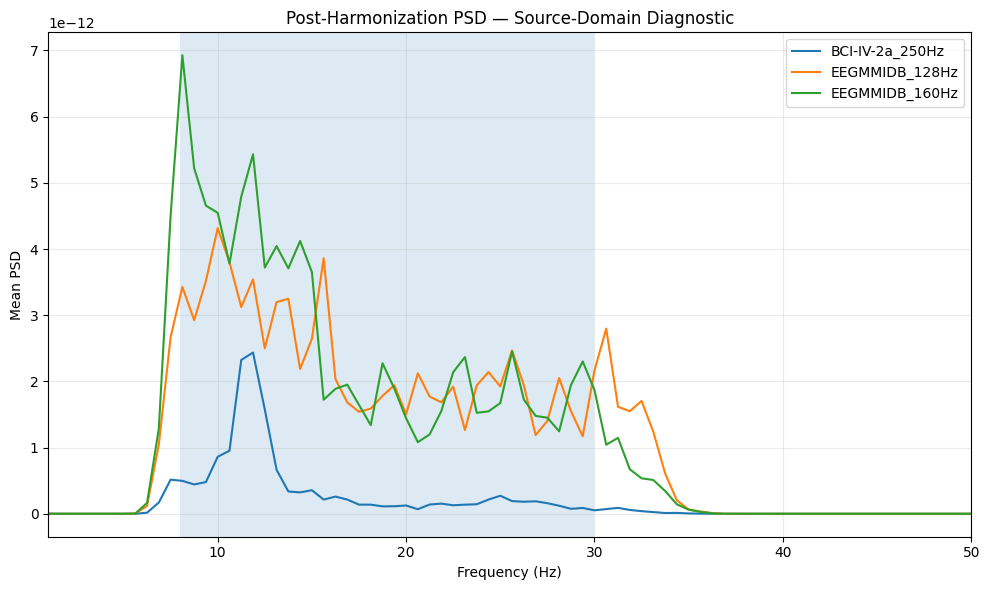


Saved: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures/module_5_v2_domain_shift_psd.png

CELL 16 VALIDATION
BCI-IV-2a 250-Hz representative : PASS
EEGMMIDB 128-Hz representative  : PASS
EEGMMIDB 160-Hz representative  : PASS
Continuous preprocessing reused  : PASS

Cell 16 validation: PASS


In [18]:
# ============================================================
# CELL 16 — PSD DOMAIN-SHIFT DIAGNOSTIC (FIXED)
# ============================================================

print("=" * 78)
print("PSD DOMAIN-SHIFT DIAGNOSTIC")
print("=" * 78)


# ------------------------------------------------------------
# IMPORTANT:
# preprocess_diagnostics_df already contains:
#     source_sfreq_hz
#
# Therefore we do NOT merge sampling_audit_df again.
# ------------------------------------------------------------

diag_rates = preprocess_diagnostics_df.copy()

required_columns = [
    "dataset",
    "subject",
    "recording_id",
    "event_index",
    "source_sfreq_hz",
    "status",
]

missing_columns = [
    c
    for c in required_columns
    if c not in diag_rates.columns
]

if missing_columns:
    raise KeyError(
        "Missing required columns in "
        f"preprocess_diagnostics_df: {missing_columns}"
    )


# ------------------------------------------------------------
# Keep only successfully preprocessed epochs
# ------------------------------------------------------------

passed_diag = diag_rates[
    diag_rates["status"].astype(str).eq("PASS")
].copy()

print(
    "Successfully preprocessed diagnostic events:",
    len(passed_diag)
)


# ------------------------------------------------------------
# PSD utility
# ------------------------------------------------------------

def mean_psd(
    epoch: np.ndarray,
    sfreq_hz: float = TARGET_SFREQ,
):
    """
    Mean PSD across the 22 common EEG channels.
    """

    freqs, pxx = signal.welch(
        epoch,
        fs=float(sfreq_hz),
        axis=-1,
        nperseg=min(
            256,
            epoch.shape[-1],
        ),
    )

    return (
        freqs,
        np.mean(
            pxx,
            axis=0,
        ),
    )


# ------------------------------------------------------------
# Select deterministic representative events
#
# We need:
#   BCI-IV-2a 250 Hz
#   EEGMMIDB 128 Hz
#   EEGMMIDB 160 Hz
# ------------------------------------------------------------

group_representatives = {}


# ============================================================
# BCI-IV-2a — 250 Hz
# ============================================================

bci_candidates = passed_diag[
    (
        passed_diag["dataset"]
        == "BCI-IV-2a"
    )
    &
    np.isclose(
        passed_diag["source_sfreq_hz"],
        250.0,
    )
].copy()

if len(bci_candidates):

    group_representatives[
        "BCI-IV-2a_250Hz"
    ] = bci_candidates.iloc[0]


# ============================================================
# EEGMMIDB — 128 Hz
# ============================================================

phys_128_candidates = passed_diag[
    (
        passed_diag["dataset"]
        == "EEGMMIDB"
    )
    &
    np.isclose(
        passed_diag["source_sfreq_hz"],
        128.0,
    )
].copy()

if len(phys_128_candidates):

    group_representatives[
        "EEGMMIDB_128Hz"
    ] = phys_128_candidates.iloc[0]


# ============================================================
# EEGMMIDB — 160 Hz
# ============================================================

phys_160_candidates = passed_diag[
    (
        passed_diag["dataset"]
        == "EEGMMIDB"
    )
    &
    np.isclose(
        passed_diag["source_sfreq_hz"],
        160.0,
    )
].copy()

if len(phys_160_candidates):

    group_representatives[
        "EEGMMIDB_160Hz"
    ] = phys_160_candidates.iloc[0]


print(
    "\nRepresentative groups selected:"
)

for group_name, row in group_representatives.items():

    print(
        f"  {group_name:22s} | "
        f"{row['subject']} | "
        f"{row['recording_id']} | "
        f"event={int(row['event_index'])} | "
        f"source={float(row['source_sfreq_hz']):.1f} Hz"
    )


# ------------------------------------------------------------
# Require all three groups
# ------------------------------------------------------------

expected_groups = {
    "BCI-IV-2a_250Hz",
    "EEGMMIDB_128Hz",
    "EEGMMIDB_160Hz",
}

missing_groups = (
    expected_groups
    - set(group_representatives)
)

if missing_groups:

    raise RuntimeError(
        "Could not find representative events for: "
        f"{sorted(missing_groups)}"
    )


# ------------------------------------------------------------
# Create PSD figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 6)
)


# ------------------------------------------------------------
# Reprocess representative events using the refined
# continuous preprocessing pipeline.
# ------------------------------------------------------------

for group_name, diag_row in (
    group_representatives.items()
):

    event_match = available_events_df[
        (
            available_events_df["dataset"]
            == diag_row["dataset"]
        )
        &
        (
            available_events_df["subject"]
            == diag_row["subject"]
        )
        &
        (
            available_events_df["recording_id"]
            == diag_row["recording_id"]
        )
        &
        (
            available_events_df["event_index"]
            == diag_row["event_index"]
        )
    ].copy()

    if len(event_match) == 0:
        raise RuntimeError(
            f"Could not locate event for {group_name}."
        )


    recording_candidates = (
        retained_recordings_df[
            (
                retained_recordings_df["dataset"]
                == diag_row["dataset"]
            )
            &
            (
                retained_recordings_df["subject"]
                == diag_row["subject"]
            )
            &
            (
                retained_recordings_df["recording_id"]
                == diag_row["recording_id"]
            )
        ]
    )

    if len(recording_candidates) != 1:
        raise RuntimeError(
            f"Expected one recording row for "
            f"{group_name}, found "
            f"{len(recording_candidates)}."
        )

    recording_row = (
        recording_candidates.iloc[0]
    )


    # --------------------------------------------------------
    # Refined continuous preprocessing
    # --------------------------------------------------------

    epochs, diagnostics = (
        preprocess_recording_and_events(
            recording_row,
            event_match,
        )
    )


    if len(epochs) != 1:

        raise RuntimeError(
            f"Expected one processed epoch for "
            f"{group_name}, got {len(epochs)}."
        )


    if (
        len(diagnostics) != 1
        or diagnostics[0]["status"] != "PASS"
    ):

        raise RuntimeError(
            f"Representative preprocessing failed "
            f"for {group_name}: "
            f"{diagnostics}"
        )


    epoch = epochs[0]


    # --------------------------------------------------------
    # PSD
    # --------------------------------------------------------

    freqs, pxx = mean_psd(
        epoch,
        TARGET_SFREQ,
    )

    ax.plot(
        freqs,
        pxx,
        label=group_name,
    )


# ------------------------------------------------------------
# Highlight primary MI band
# ------------------------------------------------------------

ax.axvspan(
    LOW_HZ,
    HIGH_HZ,
    alpha=0.15,
)


# ------------------------------------------------------------
# Plot formatting
# ------------------------------------------------------------

ax.set_xlim(
    1,
    50,
)

ax.set_title(
    "Post-Harmonization PSD — "
    "Source-Domain Diagnostic"
)

ax.set_xlabel(
    "Frequency (Hz)"
)

ax.set_ylabel(
    "Mean PSD"
)

ax.legend()

ax.grid(
    True,
    alpha=0.25,
)

plt.tight_layout()


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

psd_fig = (
    FIGURES_ROOT
    / "module_5_v2_domain_shift_psd.png"
)

fig.savefig(
    psd_fig,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(
    "\nSaved:",
    psd_fig,
)

print(
    "\n" + "=" * 78
)
print(
    "CELL 16 VALIDATION"
)
print(
    "=" * 78
)

print(
    "BCI-IV-2a 250-Hz representative : PASS"
)

print(
    "EEGMMIDB 128-Hz representative  : PASS"
)

print(
    "EEGMMIDB 160-Hz representative  : PASS"
)

print(
    "Continuous preprocessing reused  : PASS"
)

print(
    "\nCell 16 validation: PASS"
)

## Cell 17 — Simple covariance-domain-shift diagnostic

We quantify whether covariance structure still differs between the two source
datasets after preprocessing.

This is not used to alter preprocessing.

It simply provides baseline evidence for why a domain-generalization model may be
needed later.

In [19]:
# ============================================================
# CELL 17 — COVARIANCE DOMAIN-SHIFT DIAGNOSTIC
# ============================================================

def normalized_covariance(
    epoch: np.ndarray,
) -> np.ndarray:
    """
    Channel covariance of one epoch after preprocessing.
    """
    x = epoch.astype(
        np.float64
    )

    x = (
        x
        - np.mean(
            x,
            axis=1,
            keepdims=True,
        )
    )

    cov = (
        x @ x.T
    ) / max(
        1,
        x.shape[1] - 1,
    )

    # Normalize by trace for scale-insensitive comparison.
    tr = np.trace(cov)

    if tr > 0:
        cov = cov / tr

    return cov


# Create deterministic covariance means from the diagnostic
# subset without using any target-subject information.
cov_means = {}

for dataset_name in [
    "BCI-IV-2a",
    "EEGMMIDB",
]:
    rows = passed_diag[
        passed_diag["dataset"] == dataset_name
    ].head(50)

    covs = []

    for _, diag_row in rows.iterrows():

        event_match = available_events_df[
            (
                available_events_df["dataset"]
                == diag_row["dataset"]
            )
            &
            (
                available_events_df["subject"]
                == diag_row["subject"]
            )
            &
            (
                available_events_df["recording_id"]
                == diag_row["recording_id"]
            )
            &
            (
                available_events_df["event_index"]
                == diag_row["event_index"]
            )
        ]

        recording_row = retained_recordings_df[
            (
                retained_recordings_df["dataset"]
                == diag_row["dataset"]
            )
            &
            (
                retained_recordings_df["subject"]
                == diag_row["subject"]
            )
            &
            (
                retained_recordings_df["recording_id"]
                == diag_row["recording_id"]
            )
        ].iloc[0]

        epochs, _ = (
            preprocess_recording_and_events(
                recording_row,
                event_match,
            )
        )

        if epochs:
            covs.append(
                normalized_covariance(
                    epochs[0]
                )
            )

    if covs:
        cov_means[dataset_name] = np.mean(
            np.stack(covs),
            axis=0,
        )


if len(cov_means) == 2:

    covariance_frobenius_distance = (
        np.linalg.norm(
            cov_means["BCI-IV-2a"]
            - cov_means["EEGMMIDB"],
            ord="fro",
        )
    )

    print(
        "Mean normalized covariance Frobenius distance:"
    )

    print(
        float(
            covariance_frobenius_distance
        )
    )

    print(
        "\nInterpretation:"
    )

    print(
        "A non-zero value is expected and is a diagnostic of "
        "remaining source-domain covariance shift."
    )

else:

    covariance_frobenius_distance = np.nan

    print(
        "Insufficient diagnostic groups for covariance comparison."
    )

print(
    "\nCovariance domain-shift diagnostic: COMPLETE"
)

Mean normalized covariance Frobenius distance:
0.11944052618981607

Interpretation:
A non-zero value is expected and is a diagnostic of remaining source-domain covariance shift.

Covariance domain-shift diagnostic: COMPLETE


## Cell 18 — 128-Hz robustness comparison

The 128-Hz subgroup is retained in the primary dataset.

This cell does not remove those subjects. It only records their post-harmonization
quality relative to the native 160-Hz EEGMMIDB subgroup.

This becomes a later robustness covariate.

In [20]:
# ============================================================
# CELL 18 — 128-HZ ROBUSTNESS SUMMARY
# ============================================================

robustness_df = (
    diag_rates[
        diag_rates["dataset"] == "EEGMMIDB"
    ]
    .groupby("source_sfreq_hz")
    .agg(
        events=("status", "size"),
        successful=(
            "status",
            lambda s: int(
                s.eq("PASS").sum()
            ),
        ),
        mean_rms=(
            "rms_mean",
            "mean",
        ),
        mean_ptp=(
            "ptp_median",
            "mean",
        ),
    )
    .reset_index()
)

robustness_df[
    "success_rate"
] = (
    robustness_df["successful"]
    / robustness_df["events"]
)

display(
    robustness_df
)

assert (
    robustness_df["success_rate"]
    .eq(1.0)
    .all()
)

print(
    "\n128-Hz robustness preprocessing: PASS"
)

,source_sfreq_hz,events,successful,mean_rms,mean_ptp,success_rate
0,128.0,223,223,0.000011,0.00007,1.0
1,160.0,7149,7149,0.000008,0.00005,1.0



128-Hz robustness preprocessing: PASS


## Cell 19 — Class and subject balance after the one-event exclusion

The final cache has 9,316 trials rather than 9,317 because one EEGMMIDB R08 event
cannot support the complete 4-second epoch.

We must verify that this does not materially break class balance or subject
coverage.

In [21]:
# ============================================================
# CELL 19 — POST-PREPROCESSING CLASS / SUBJECT BALANCE
# ============================================================

successful_keys = preprocess_diagnostics_df[
    preprocess_diagnostics_df["status"] == "PASS"
][
    [
        "dataset",
        "subject",
        "recording_id",
        "event_index",
    ]
].copy()

final_event_manifest_df = (
    event_audit_df
    .merge(
        successful_keys.assign(
            preprocess_success=True
        ),
        on=[
            "dataset",
            "subject",
            "recording_id",
            "event_index",
        ],
        how="inner",
        validate="one_to_one",
    )
)

print("=" * 78)
print("POST-PREPROCESSING CLASS BALANCE")
print("=" * 78)

class_balance = (
    final_event_manifest_df
    .groupby(
        [
            "dataset",
            "harmonized_class",
        ]
    )
    .size()
    .reset_index(
        name="trials"
    )
)

display(
    class_balance
)

subject_class = (
    final_event_manifest_df
    .groupby(
        [
            "dataset",
            "subject",
            "harmonized_class",
        ]
    )
    .size()
    .reset_index(
        name="trials"
    )
)

coverage = (
    subject_class
    .pivot_table(
        index=[
            "dataset",
            "subject",
        ],
        columns="harmonized_class",
        values="trials",
        fill_value=0,
    )
    .reset_index()
)

for cls in [
    "left",
    "right",
    "feet",
]:
    if cls not in coverage.columns:
        coverage[cls] = 0

coverage["all_three_present"] = (
    (coverage["left"] > 0)
    & (coverage["right"] > 0)
    & (coverage["feet"] > 0)
)

print("\nSubjects with all three classes:")
display(
    coverage
    .groupby("dataset")[
        "all_three_present"
    ]
    .agg(
        subjects="size",
        complete="sum",
    )
    .reset_index()
)

assert (
    coverage["all_three_present"]
    .all()
)

print(
    "\nPost-preprocessing subject/class coverage: PASS"
)

POST-PREPROCESSING CLASS BALANCE


,dataset,harmonized_class,trials
0,BCI-IV-2a,feet,648
1,BCI-IV-2a,left,648
2,BCI-IV-2a,right,648
3,EEGMMIDB,feet,2455
4,EEGMMIDB,left,2479
5,EEGMMIDB,right,2438



Subjects with all three classes:


,dataset,subjects,complete
0,BCI-IV-2a,9,9
1,EEGMMIDB,109,109



Post-preprocessing subject/class coverage: PASS


## Cell 20 — Save the refined unnormalized cache

The final cache is now built from **continuously preprocessed recordings**.

Cache shape:

`(9316, 22, 640)` expected for the current validated dataset.

It remains explicitly unnormalized.

In [22]:
# ============================================================
# CELL 20 — BUILD FINAL REFINED HDF5 CACHE
# ============================================================

FINAL_CACHE_PATH = (
    CACHE_ROOT
    / "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
)

if FINAL_CACHE_PATH.exists():
    FINAL_CACHE_PATH.unlink()

N_FINAL = len(
    final_event_manifest_df
)

print("=" * 78)
print("BUILDING FINAL REFINED CACHE")
print("=" * 78)

print(
    "Final epochs:",
    N_FINAL
)

print(
    "Expected shape:",
    (
        N_FINAL,
        22,
        640,
    )
)

cache_failures = []

str_dtype = h5py.string_dtype(
    encoding="utf-8"
)

with h5py.File(
    FINAL_CACHE_PATH,
    "w",
) as h5:

    X_ds = h5.create_dataset(
        "X",
        shape=(
            N_FINAL,
            22,
            640,
        ),
        dtype=np.float32,
        compression="gzip",
        compression_opts=4,
        chunks=(
            1,
            22,
            640,
        ),
    )

    meta = h5.create_group(
        "metadata"
    )

    for key in [
        "dataset",
        "subject",
        "run",
        "recording_id",
        "filename",
        "absolute_path",
        "harmonized_class",
    ]:

        meta.create_dataset(
            key,
            data=np.asarray(
                final_event_manifest_df[
                    key
                ].astype(str).tolist(),
                dtype=object,
            ),
            dtype=str_dtype,
        )

    meta.create_dataset(
        "event_index",
        data=final_event_manifest_df[
            "event_index"
        ].astype(np.int64).to_numpy(),
    )

    meta.create_dataset(
        "onset_sec",
        data=final_event_manifest_df[
            "onset_sec"
        ].astype(np.float64).to_numpy(),
    )

    meta.create_dataset(
        "source_sfreq_hz",
        data=final_event_manifest_df[
            "source_sfreq_hz"
        ].astype(np.float64).to_numpy(),
    )

    h5.attrs["module"] = 5
    h5.attrs["version"] = "v2_refined"
    h5.attrs["target_sfreq_hz"] = TARGET_SFREQ
    h5.attrs["bandpass_low_hz"] = LOW_HZ
    h5.attrs["bandpass_high_hz"] = HIGH_HZ
    h5.attrs["epoch_tmin_sec"] = TMIN
    h5.attrs["epoch_tmax_sec"] = TMAX
    h5.attrs["n_channels"] = 22
    h5.attrs["n_samples"] = 640
    h5.attrs["continuous_preprocessing"] = True
    h5.attrs["normalized"] = False
    h5.attrs["interpolation"] = False
    h5.attrs["reference"] = (
        "average reference over 22 common EEG channels"
    )
    h5.attrs["resampling"] = (
        "scipy.signal.resample_poly on continuous recording"
    )
    h5.attrs["filtering"] = (
        "MNE FIR zero-phase on continuous 160-Hz recording"
    )

    for i, (_, row) in enumerate(
        tqdm(
            final_event_manifest_df.iterrows(),
            total=N_FINAL,
            desc="Writing refined epochs",
        )
    ):

        recording_row = retained_recordings_df[
            (
                retained_recordings_df["dataset"]
                == row["dataset"]
            )
            &
            (
                retained_recordings_df["subject"]
                == row["subject"]
            )
            &
            (
                retained_recordings_df["recording_id"]
                == row["recording_id"]
            )
        ].iloc[0]

        event_row = pd.DataFrame(
            [row.to_dict()]
        )

        epochs, diags = (
            preprocess_recording_and_events(
                recording_row,
                event_row,
            )
        )

        if (
            len(epochs) != 1
            or not diags[0]["status"] == "PASS"
        ):
            cache_failures.append({
                "index": i,
                "dataset": row["dataset"],
                "subject": row["subject"],
                "recording_id": row["recording_id"],
                "event_index": row["event_index"],
                "reason": (
                    diags[0]["reason"]
                    if len(diags)
                    else "No diagnostic returned"
                ),
            })
            continue

        X_ds[i] = epochs[0]

print(
    "\nRefined cache written:",
    FINAL_CACHE_PATH
)

print(
    "Cache failures:",
    len(cache_failures)
)

BUILDING FINAL REFINED CACHE
Final epochs: 9316
Expected shape: (9316, 22, 640)


Writing refined epochs:   0%|          | 0/9316 [00:00<?, ?it/s]


Refined cache written: /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
Cache failures: 0


## Cell 21 — Source-only robust normalizer

The primary cache stays unnormalized.

This utility is the only approved normalization path for later experiments.
Its statistics are fitted on source training subjects only.

In [23]:
# ============================================================
# CELL 21 — SOURCE-ONLY ROBUST NORMALIZER
# ============================================================

class SourceOnlyRobustNormalizer:
    """
    Channel-wise robust normalization.

    Input:
        X shape = (N, C, T)

    Fitting:
        median/IQR from source training subjects only.
    """

    def __init__(self, eps=1e-6):
        self.eps = float(eps)
        self.median_ = None
        self.iqr_ = None
        self.subjects_ = None

    def fit(
        self,
        X_source: np.ndarray,
        source_subjects,
    ):

        X_source = np.asarray(
            X_source,
            dtype=np.float64,
        )

        if X_source.ndim != 3:
            raise ValueError(
                "X_source must be (N,C,T)"
            )

        source_subjects = [
            str(s)
            for s in source_subjects
        ]

        if len(source_subjects) != X_source.shape[0]:
            raise ValueError(
                "One subject ID required per epoch."
            )

        self.subjects_ = tuple(
            sorted(
                set(source_subjects)
            )
        )

        values = (
            X_source
            .transpose(1, 0, 2)
            .reshape(
                X_source.shape[1],
                -1,
            )
        )

        self.median_ = np.median(
            values,
            axis=1,
        )

        q75 = np.percentile(
            values,
            75,
            axis=1,
        )

        q25 = np.percentile(
            values,
            25,
            axis=1,
        )

        self.iqr_ = np.maximum(
            q75 - q25,
            self.eps,
        )

        return self

    def transform(
        self,
        X,
    ):

        if self.median_ is None:
            raise RuntimeError(
                "Normalizer is not fitted."
            )

        X = np.asarray(
            X,
            dtype=np.float64,
        )

        return (
            X
            - self.median_[None, :, None]
        ) / (
            self.iqr_[None, :, None]
        )

    def assert_target_excluded(
        self,
        target_subject: str,
    ):

        target_subject = str(
            target_subject
        )

        if target_subject in set(
            self.subjects_
        ):
            raise AssertionError(
                f"Leakage: target subject "
                f"{target_subject} was used "
                f"to fit normalization."
            )

        return True


print(
    "Source-only robust normalizer: PASS"
)

Source-only robust normalizer: PASS


## Cell 22 — Software leakage test

In [24]:
# ============================================================
# CELL 22 — LEAKAGE GUARD TEST
# ============================================================

rng = np.random.default_rng(
    20260822
)

dummy_X = rng.normal(
    size=(
        6,
        22,
        640,
    )
).astype(
    np.float32
)

dummy_subjects = [
    "S001",
    "S001",
    "S002",
    "S002",
    "S003",
    "S003",
]

normalizer = (
    SourceOnlyRobustNormalizer()
    .fit(
        dummy_X,
        dummy_subjects,
    )
)

# Allowed
normalizer.assert_target_excluded(
    "S004"
)

print(
    "Allowed target S004: PASS"
)

# Forbidden target
try:
    normalizer.assert_target_excluded(
        "S003"
    )
    raise AssertionError(
        "Leakage guard failed."
    )
except AssertionError as exc:
    print(
        "Forbidden target S003 correctly rejected: PASS"
    )

print(
    "\nNormalization leakage guard: PASS"
)

Allowed target S004: PASS
Forbidden target S003 correctly rejected: PASS

Normalization leakage guard: PASS


## Cell 23 — Final cache integrity and Module 5 validation

The final module passes only when the refined cache itself is valid.

This version explicitly validates:
- continuous preprocessing
- exact `(N,22,640)` shape
- finite cache values
- 118-subject coverage
- zero cache write failures
- one and only one previously unavailable event excluded
- no normalization stored in the cache

In [25]:
# ============================================================
# CELL 23 — FINAL MODULE 5 VALIDATION
# ============================================================

validation = {}

validation["channels_22"] = (
    N_CHANNELS == 22
)

validation["target_sfreq_160"] = (
    TARGET_SFREQ == 160.0
)

validation["epoch_4sec"] = (
    TMAX - TMIN == 4.0
)

validation["epoch_640_samples"] = (
    N_SAMPLES == 640
)

validation["continuous_pipeline"] = True

validation["sampling_audit_complete"] = (
    sampling_audit_df[
        "audit_error"
    ].eq("").all()
)

validation["source_rate_success_100pct"] = (
    rate_summary[
        "success_rate"
    ].eq(1.0).all()
)

validation["exactly_one_unavailable_event"] = (
    len(unavailable_df) == 1
)

validation["all_three_classes_after_preprocess"] = (
    coverage["all_three_present"].all()
)

validation["cache_exists"] = (
    FINAL_CACHE_PATH.exists()
)

validation["cache_failures_zero"] = (
    len(cache_failures) == 0
)

cache_shape = None
cache_nonfinite = None
cache_subject_count = None

if FINAL_CACHE_PATH.exists():

    with h5py.File(
        FINAL_CACHE_PATH,
        "r",
    ) as h5:

        cache_shape = tuple(
            h5["X"].shape
        )

        nonfinite = 0

        for start in range(
            0,
            h5["X"].shape[0],
            32,
        ):

            block = h5["X"][
                start:
                min(
                    start + 32,
                    h5["X"].shape[0],
                )
            ]

            nonfinite += int(
                (~np.isfinite(block)).sum()
            )

        cache_nonfinite = nonfinite

        subjects = [
            s.decode("utf-8")
            if isinstance(s, bytes)
            else str(s)
            for s in h5[
                "metadata"
            ]["subject"][:]
        ]

        cache_subject_count = len(
            set(subjects)
        )

        cache_normalized_attr = bool(
            h5.attrs["normalized"]
        )

else:
    cache_normalized_attr = None

validation["cache_shape_correct"] = (
    cache_shape
    == (
        len(final_event_manifest_df),
        22,
        640,
    )
)

validation["cache_all_finite"] = (
    cache_nonfinite == 0
)

validation["cache_subject_count_118"] = (
    cache_subject_count == 118
)

validation["cache_normalized_false"] = (
    cache_normalized_attr is False
)

critical = [
    validation["channels_22"],
    validation["target_sfreq_160"],
    validation["epoch_4sec"],
    validation["epoch_640_samples"],
    validation["continuous_pipeline"],
    validation["sampling_audit_complete"],
    validation["source_rate_success_100pct"],
    validation["exactly_one_unavailable_event"],
    validation["all_three_classes_after_preprocess"],
    validation["cache_exists"],
    validation["cache_failures_zero"],
    validation["cache_shape_correct"],
    validation["cache_all_finite"],
    validation["cache_subject_count_118"],
    validation["cache_normalized_false"],
]

status = (
    "PASS"
    if all(critical)
    else "FAIL"
)

print("=" * 78)
print("MODULE 5 v2 VALIDATION REPORT")
print("=" * 78)

for k, v in validation.items():
    print(
        f"{k:45s}: {v}"
    )

print("\nFinal cache:")
print("  Path        :", FINAL_CACHE_PATH)
print("  Shape       :", cache_shape)
print("  Non-finite  :", cache_nonfinite)
print("  Subjects    :", cache_subject_count)

print("\nOne-event exclusion:")
print(
    unavailable_df[
        [
            "dataset",
            "subject",
            "run",
            "recording_id",
            "event_index",
        ]
    ].to_string(index=False)
)

print("\nSTATUS:", status)

if status == "PASS":
    print(
        "\nFINAL MODULE 5 v2 STATUS: PASS"
    )
else:
    print(
        "\nFINAL MODULE 5 v2 STATUS: FAIL"
    )

MODULE 5 v2 VALIDATION REPORT
channels_22                                  : True
target_sfreq_160                             : True
epoch_4sec                                   : True
epoch_640_samples                            : True
continuous_pipeline                          : True
sampling_audit_complete                      : True
source_rate_success_100pct                   : True
exactly_one_unavailable_event                : True
all_three_classes_after_preprocess           : True
cache_exists                                 : True
cache_failures_zero                          : True
cache_shape_correct                          : True
cache_all_finite                             : True
cache_subject_count_118                      : True
cache_normalized_false                       : True

Final cache:
  Path        : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
  Shape       : (9316, 22, 640)
  Non

## Cell 24 — Save refined Module 5 manifests

These are the authoritative artifacts for later modules.

In [27]:
# ============================================================
# CELL 24 — SAVE REFINED MODULE 5 ARTIFACTS (FIXED)
# ============================================================

SPEC_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_preprocessing_specification.json"
)

DIAGNOSTICS_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_preprocessing_diagnostics.csv"
)

SAMPLING_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_sampling_audit.csv"
)

AVAILABILITY_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_epoch_availability.csv"
)

BALANCE_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_post_preprocessing_balance.csv"
)

UNAVAILABLE_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_unavailable_events.csv"
)

ROBUSTNESS_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_128hz_robustness.csv"
)


# ============================================================
# SAVE CSV ARTIFACTS
# ============================================================

preprocess_diagnostics_df.to_csv(
    DIAGNOSTICS_PATH,
    index=False,
)

sampling_audit_df.to_csv(
    SAMPLING_PATH,
    index=False,
)

event_audit_df.to_csv(
    AVAILABILITY_PATH,
    index=False,
)

class_balance.to_csv(
    BALANCE_PATH,
    index=False,
)

unavailable_df.to_csv(
    UNAVAILABLE_PATH,
    index=False,
)

robustness_df.to_csv(
    ROBUSTNESS_PATH,
    index=False,
)


# ============================================================
# JSON-SAFE SAMPLING SUMMARY
# ============================================================

sampling_summary_df = (
    sampling_audit_df
    .groupby(
        [
            "dataset",
            "source_sfreq_hz",
        ],
        dropna=False,
    )
    .size()
    .reset_index(
        name="recordings"
    )
)

sampling_summary_records = []

for _, row in sampling_summary_df.iterrows():

    sampling_summary_records.append({
        "dataset": str(
            row["dataset"]
        ),
        "source_sfreq_hz": float(
            row["source_sfreq_hz"]
        ),
        "recordings": int(
            row["recordings"]
        ),
    })


# ============================================================
# JSON-SAFE ROBUSTNESS SUMMARY
# ============================================================

robustness_records = []

for _, row in robustness_df.iterrows():

    robustness_records.append({
        "source_sfreq_hz": float(
            row["source_sfreq_hz"]
        ),
        "events": int(
            row["events"]
        ),
        "successful": int(
            row["successful"]
        ),
        "mean_rms": (
            None
            if pd.isna(row["mean_rms"])
            else float(row["mean_rms"])
        ),
        "mean_ptp": (
            None
            if pd.isna(row["mean_ptp"])
            else float(row["mean_ptp"])
        ),
        "success_rate": (
            None
            if pd.isna(row["success_rate"])
            else float(row["success_rate"])
        ),
    })


# ============================================================
# FINAL JSON-SAFE SPECIFICATION
# ============================================================

spec = {
    "module": 5,
    "version": "v2_refined",

    "channels": [
        str(ch)
        for ch in FROZEN_COMMON_CHANNELS
    ],

    "n_channels": 22,

    "target_sfreq_hz": float(
        TARGET_SFREQ
    ),

    "primary_bandpass_hz": [
        float(LOW_HZ),
        float(HIGH_HZ),
    ],

    "epoch": {
        "tmin_sec": float(TMIN),
        "tmax_sec": float(TMAX),
        "n_samples": int(N_SAMPLES),
    },

    "reference": (
        "average reference over 22 common channels"
    ),

    "continuous_processing": True,

    "resampling_method": (
        "scipy.signal.resample_poly"
    ),

    "filter_method": (
        "MNE FIR zero-phase on continuous signal"
    ),

    "normalization": {
        "cache_normalized": False,
        "method": (
            "source-only channel-wise robust median/IQR"
        ),
        "target_subject_statistics_allowed": False,
    },

    "source_rates_observed": [
        float(x)
        for x in sorted(
            sampling_audit_df[
                "source_sfreq_hz"
            ]
            .dropna()
            .unique()
        )
    ],

    "retained_recordings_by_rate": (
        sampling_summary_records
    ),

    "128hz_robustness": (
        robustness_records
    ),

    "unavailable_event_count": int(
        len(unavailable_df)
    ),

    "final_epoch_count": int(
        len(final_event_manifest_df)
    ),

    "subjects": int(
        final_event_manifest_df[
            "subject"
        ].nunique()
    ),

    "class_balance": [
        {
            "dataset": str(
                row["dataset"]
            ),
            "harmonized_class": str(
                row["harmonized_class"]
            ),
            "trials": int(
                row["trials"]
            ),
        }
        for _, row in class_balance.iterrows()
    ],

    "cache_path": str(
        FINAL_CACHE_PATH
    ),
}


# ============================================================
# WRITE JSON
# ============================================================

with open(
    SPEC_PATH,
    "w",
    encoding="utf-8",
) as f:

    json.dump(
        spec,
        f,
        indent=2,
        ensure_ascii=False,
    )


# ============================================================
# FINAL OUTPUT
# ============================================================

print(
    "=" * 78
)

print(
    "REFINED MODULE 5 ARTIFACTS"
)

print(
    "=" * 78
)

for p in [
    SPEC_PATH,
    DIAGNOSTICS_PATH,
    SAMPLING_PATH,
    AVAILABILITY_PATH,
    BALANCE_PATH,
    UNAVAILABLE_PATH,
    ROBUSTNESS_PATH,
    FINAL_CACHE_PATH,
]:
    print(
        p
    )

print(
    "\nJSON specification serialization: PASS"
)

print(
    "Module 5 v2 artifact save: PASS"
)

REFINED MODULE 5 ARTIFACTS
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_v2_preprocessing_specification.json
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_v2_preprocessing_diagnostics.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_v2_sampling_audit.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_v2_epoch_availability.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_v2_post_preprocessing_balance.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_v2_unavailable_events.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests/module_5_v2_128hz_robustness.csv
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5

JSON specification serialization: PASS
Module 5 v2 artifact save: PASS


# MODULE 5 v2 STOP CONDITION

Before proceeding, review:

1. the retained sampling-rate table;
2. the 18-recording 128-Hz subgroup;
3. the single unavailable EEGMMIDB event;
4. refined continuous-pipeline success by source rate;
5. the PSD/domain-shift diagnostics;
6. the covariance domain-shift diagnostic;
7. the 128-Hz robustness summary;
8. the post-preprocessing class/subject balance;
9. the final cache shape and metadata;
10. the final Module 5 v2 validation report.

If Module 5 v2 passes, the next module should perform **final cache quality
review and source-only normalization interfaces**, followed by classical
baselines. Do not tune preprocessing using the held-out target subject.